<a href="https://colab.research.google.com/github/Saiful-2/notebooks/blob/main/SUB_Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Name: **Student Performance Prediction**
### Objective: Predict student exam scores based on study hours

In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# ============================================================
# Step 2: Load Dataset
# ============================================================

url = "http://raw.githubusercontent.com/Saiful-2/datasets/main/Students%20Performance%20.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

In [3]:
# ============================================================
# Step 3: Explore Dataset
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(145, 15)

Column Names:
Index(['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship',
       'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')

Missing Values:
Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


In [4]:
# ============================================================
# Step 4: Select Input and Output Variables
# ============================================================

# Input Feature = Study Hours
# Output Variable = Exam Score

X = df[['Weekly_Study_Hours']]
y = df['Grade']

print("\nInput Data:")
print(X.head())

print("\nOutput Data:")
print(y.head())


Input Data:
   Weekly_Study_Hours
0                   0
1                   0
2                   2
3                   2
4                  12

Output Data:
0    AA
1    AA
2    AA
3    AA
4    AA
Name: Grade, dtype: object


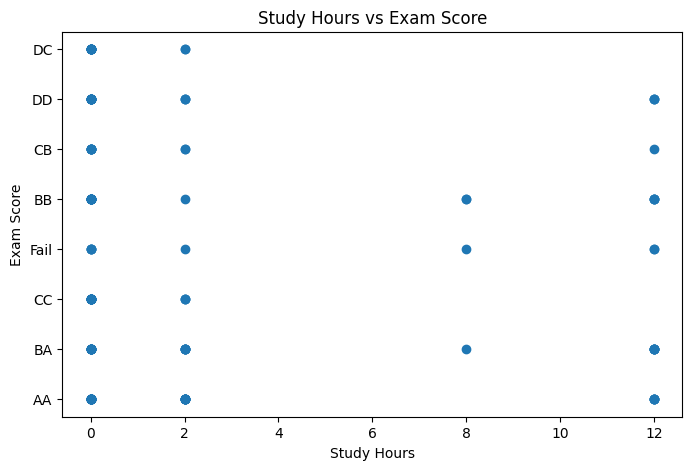

In [5]:
# ============================================================
# Step 5: Plot Study Hours vs Score
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

In [6]:
# ============================================================
# Step 6: Split Dataset into Training and Testing Data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (116, 1)
Testing Data Shape: (29, 1)


In [7]:
# ============================================================
# Step 7: Implement Linear Regression
# ============================================================

model = LinearRegression()

In [8]:
# ============================================================
# Step 8: Train the Model
# ============================================================

# Define a mapping for categorical grades to numerical values
grade_mapping = {
    'Fail': 0,
    'DD': 1,
    'DC': 2,
    'CC': 3,
    'CB': 4,
    'BB': 5,
    'BA': 6,
    'AA': 7
}

# Convert y_train to numerical values using the defined mapping
# This transformation ideally should be applied to the 'Grade' column in df before splitting X and y,
# to ensure consistency across y_train and y_test.
y_train_numeric = y_train.map(grade_mapping)

model.fit(X_train, y_train_numeric)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
# ============================================================
# Step 9: Display Model Parameters
# ============================================================

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficient:")
print(model.coef_)


Intercept:
4.413452229299363

Coefficient:
[0.03891295]


In [10]:
# ============================================================
# Step 10: Predict Scores for Test Data
# ============================================================

y_pred = model.predict(X_test)

print("\nPredicted Scores:")
print(y_pred)


Predicted Scores:
[4.41345223 4.41345223 4.41345223 4.49127813 4.41345223 4.41345223
 4.88040764 4.49127813 4.88040764 4.88040764 4.41345223 4.72475584
 4.41345223 4.41345223 4.41345223 4.88040764 4.41345223 4.41345223
 4.41345223 4.49127813 4.41345223 4.41345223 4.72475584 4.41345223
 4.41345223 4.72475584 4.41345223 4.49127813 4.41345223]


In [11]:
# ============================================================
# Step 11: Compare Actual vs Predicted Values
# ============================================================

comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred
})

print("\nActual vs Predicted Scores")
print(comparison)


Actual vs Predicted Scores
   Actual Score  Predicted Score
0            CC         4.413452
1            CC         4.413452
2            AA         4.413452
3            BB         4.491278
4            AA         4.413452
5            AA         4.413452
6            BB         4.880408
7            DC         4.491278
8            DD         4.880408
9            BA         4.880408
10         Fail         4.413452
11           BB         4.724756
12         Fail         4.413452
13           CB         4.413452
14           DC         4.413452
15           BA         4.880408
16           BA         4.413452
17           BB         4.413452
18           DC         4.413452
19           DD         4.491278
20           DC         4.413452
21         Fail         4.413452
22         Fail         4.724756
23           CC         4.413452
24           BB         4.413452
25           BB         4.724756
26           CB         4.413452
27           CB         4.491278
28           BA

In [12]:
# ============================================================
# Step 12: Predict Score for New Input
# ============================================================

study_hours = [[9]]

predicted_score = model.predict(study_hours)

print("\nPredicted Score for 9 Hours Study:")
print(predicted_score[0])


Predicted Score for 9 Hours Study:
4.763668789808918


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


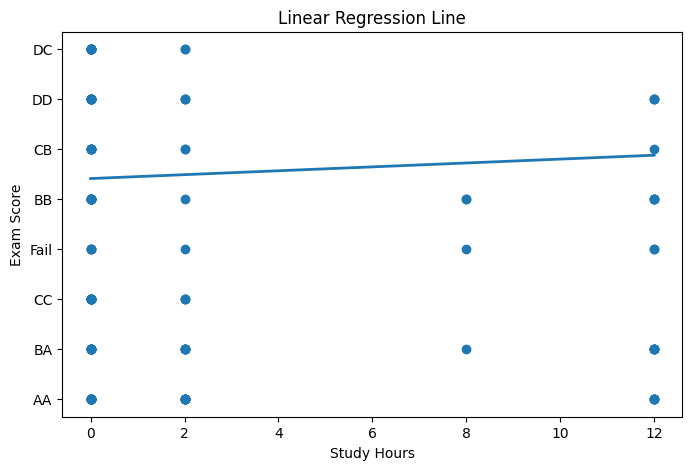

In [13]:
# ============================================================
# Step 13: Plot Regression Line
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    linewidth=2
)

plt.title("Linear Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

In [14]:
# ============================================================
# Step 14: Make Multiple Predictions
# ============================================================

new_hours = [[2], [4], [6], [8], [10]]

new_predictions = model.predict(new_hours)

result = pd.DataFrame({
    'Study Hours': [2, 4, 6, 8, 10],
    'Predicted Score': new_predictions
})

print("\nPredicted Scores for Different Study Hours:")
print(result)


Predicted Scores for Different Study Hours:
   Study Hours  Predicted Score
0            2         4.491278
1            4         4.569104
2            6         4.646930
3            8         4.724756
4           10         4.802582


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
